<a href="https://colab.research.google.com/github/nick21aka/API.PY/blob/main/EFT_MineriaDatos_IBM_Attrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Final Transversal — Minería de Datos (BIY7121)
## Predicción de Deserción Voluntaria (Attrition) — IBM HR Analytics

**Integrante(s):** Nicolás Silva — RUT: 20.726.983-2
**Fecha:** Julio 2026

**Metodología:** CRISP-DM (Comprensión del negocio → Comprensión de los datos → Preparación → Modelado → Evaluación → Despliegue)

**Objetivo:** Identificar los factores de riesgo asociados a la deserción voluntaria y construir modelos predictivos que permitan a RR.HH. pasar de una gestión reactiva a una proactiva de retención de talento.

## 1. Comprensión del Negocio

IBM enfrenta un patrón de deserción voluntaria que genera altos costos de reclutamiento, pérdida de conocimiento crítico y menor productividad. Con datos de 1.470 empleados se busca:

**Hipótesis:**
- **H1 (Sobrecarga Laboral):** empleados con horas extra (OverTime) desertan significativamente más.
- **H2 (Compensación y Antigüedad):** correlación inversa entre MonthlyIncome y deserción (menor sueldo relativo a experiencia → mayor fuga).
- **H3 (Equilibrio Vida-Trabajo):** BusinessTravel frecuente y mayor DistanceFromHome reducen la retención.

**Interrogantes:** perfil del empleado desertor, influencia de JobSatisfaction, y variables no financieras protectoras (TrainingTimesLastYear, RelationshipSatisfaction).

In [4]:
# === Librerías ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score,
                             roc_curve, silhouette_score)
from mlxtend.frequent_patterns import apriori, association_rules

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 90
RANDOM_STATE = 42
print('Librerías cargadas correctamente')

Librerías cargadas correctamente


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 2. Comprensión de los Datos (obtención y exploración inicial)

In [5]:
df = pd.read_csv('IBM_HR_Analytics_Employee.csv')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Dimensiones: 1470 filas x 35 columnas


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [6]:
# Tipos de datos, nulos y duplicados
print(df.info())
print('\nValores nulos totales:', df.isnull().sum().sum())
print('Filas duplicadas:', df.duplicated().sum())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Tasa de deserción: 16.1%  (dataset desbalanceado)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

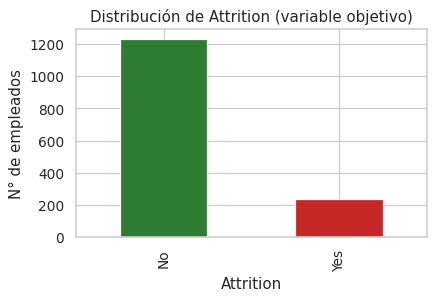

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [7]:
# Distribución de la variable objetivo
tasa = df['Attrition'].value_counts(normalize=True) * 100
print(df['Attrition'].value_counts())
print(f"\nTasa de deserción: {tasa['Yes']:.1f}%  (dataset desbalanceado)")

fig, ax = plt.subplots(figsize=(5,3.5))
df['Attrition'].value_counts().plot(kind='bar', color=['#2e7d32','#c62828'], ax=ax)
ax.set_title('Distribución de Attrition (variable objetivo)')
ax.set_ylabel('N° de empleados'); plt.tight_layout(); plt.show()

## 3. Preparación de los Datos (limpieza y transformación)

- Se eliminan variables **constantes** (EmployeeCount, Over18, StandardHours) e identificadores (EmployeeNumber): no aportan información.
- No existen valores nulos ni duplicados.
- Se revisan valores atípicos en variables monetarias (se conservan: son sueldos reales de niveles ejecutivos, no errores).
- Encoding de variables categóricas: binarias con mapeo 0/1, nominales con One-Hot Encoding.
- Escalamiento estándar (Z-score) para modelos sensibles a magnitud (Regresión Logística, K-Means, PCA).

In [8]:
# Eliminación de columnas constantes / identificadores
const_cols = [c for c in df.columns if df[c].nunique() == 1]
print('Columnas constantes detectadas:', const_cols)
df_clean = df.drop(columns=const_cols + ['EmployeeNumber'])
print('Dimensiones tras limpieza:', df_clean.shape)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Columnas constantes detectadas: ['EmployeeCount', 'Over18', 'StandardHours']
Dimensiones tras limpieza: (1470, 31)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

MonthlyIncome: 114 valores fuera de rango IQR
DistanceFromHome: 0 valores fuera de rango IQR
YearsAtCompany: 104 valores fuera de rango IQR


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

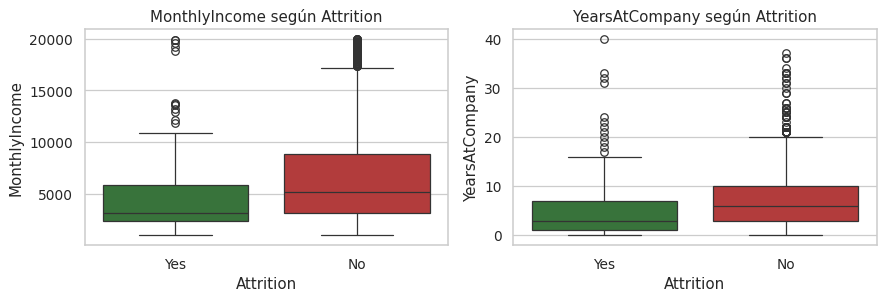

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [9]:
# Outliers: revisión con IQR sobre variables monetarias
for col in ['MonthlyIncome', 'DistanceFromHome', 'YearsAtCompany']:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df_clean[col] < q1 - 1.5*iqr) | (df_clean[col] > q3 + 1.5*iqr)).sum()
    print(f'{col}: {n_out} valores fuera de rango IQR')
# Decisión: se CONSERVAN. Son valores plausibles (gerentes con sueldos altos, empleados antiguos),
# eliminarlos sesgaría el análisis de los "Top Performers" que interesan al negocio.
fig, ax = plt.subplots(1, 2, figsize=(10,3.5))
sns.boxplot(data=df_clean, x='Attrition', y='MonthlyIncome', ax=ax[0], palette=['#2e7d32','#c62828'])
ax[0].set_title('MonthlyIncome según Attrition')
sns.boxplot(data=df_clean, x='Attrition', y='YearsAtCompany', ax=ax[1], palette=['#2e7d32','#c62828'])
ax[1].set_title('YearsAtCompany según Attrition')
plt.tight_layout(); plt.show()

## 4. Análisis Exploratorio (EDA) y contraste de hipótesis

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Attrition    No   Yes
OverTime             
No         89.6  10.4
Yes        69.5  30.5

Chi2 = 87.56, p-valor = 8.16e-21
H1 SE CONFIRMA


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

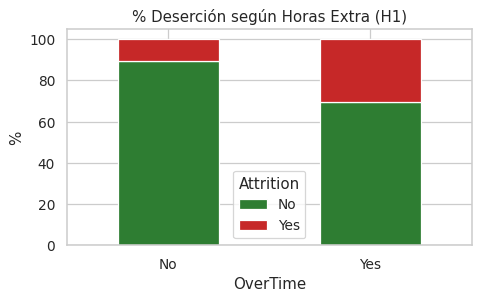

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [10]:
# H1 — Sobrecarga laboral: OverTime vs Attrition (test Chi-cuadrado)
ct = pd.crosstab(df_clean['OverTime'], df_clean['Attrition'], normalize='index') * 100
print(ct.round(1))
chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(df_clean['OverTime'], df_clean['Attrition']))
print(f'\nChi2 = {chi2:.2f}, p-valor = {p:.2e}')
print('H1 SE CONFIRMA' if p < 0.05 else 'H1 no se confirma')

ct.plot(kind='bar', stacked=True, color=['#2e7d32','#c62828'], figsize=(5.5,3.5))
plt.title('% Deserción según Horas Extra (H1)'); plt.ylabel('%'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

In [11]:
# H2 — Compensación: MonthlyIncome vs Attrition (test Mann-Whitney, distribución no normal)
inc_yes = df_clean.loc[df_clean['Attrition']=='Yes','MonthlyIncome']
inc_no  = df_clean.loc[df_clean['Attrition']=='No','MonthlyIncome']
u, p = stats.mannwhitneyu(inc_yes, inc_no)
print(f'Mediana sueldo desertores: ${inc_yes.median():,.0f} | No desertores: ${inc_no.median():,.0f}')
print(f'Mann-Whitney U, p-valor = {p:.2e} ->', 'H2 SE CONFIRMA' if p<0.05 else 'H2 no se confirma')

# Sueldo relativo a experiencia (ratio ingreso / años de experiencia)
df_clean['IncomePerYearExp'] = df_clean['MonthlyIncome'] / (df_clean['TotalWorkingYears'] + 1)
print('\nMediana Ingreso/AñoExperiencia — Yes: {:.0f} | No: {:.0f}'.format(
    df_clean.loc[df_clean['Attrition']=='Yes','IncomePerYearExp'].median(),
    df_clean.loc[df_clean['Attrition']=='No','IncomePerYearExp'].median()))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Mediana sueldo desertores: $3,202 | No desertores: $5,204
Mann-Whitney U, p-valor = 2.95e-14 -> H2 SE CONFIRMA

Mediana Ingreso/AñoExperiencia — Yes: 588 | No: 539


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Attrition            No   Yes
BusinessTravel               
Non-Travel         92.0   8.0
Travel_Frequently  75.1  24.9
Travel_Rarely      85.0  15.0
BusinessTravel: Chi2=24.18, p=0.0000
DistanceFromHome: mediana Yes=9 km, No=7 km, p=0.0024
H3 SE CONFIRMA (ambas variables significativas)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

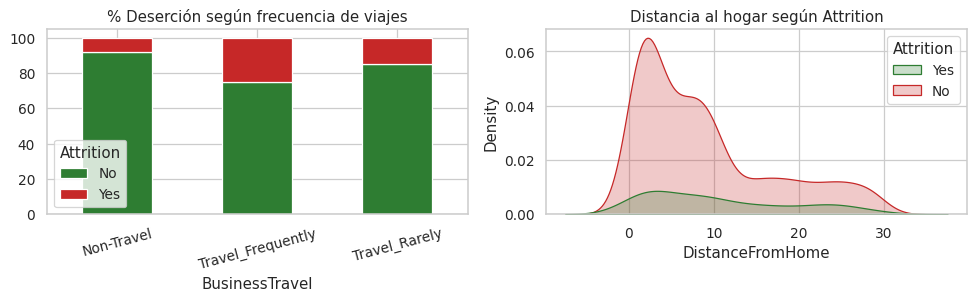

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [12]:
# H3 — Equilibrio vida-trabajo: BusinessTravel y DistanceFromHome
ct3 = pd.crosstab(df_clean['BusinessTravel'], df_clean['Attrition'], normalize='index')*100
print(ct3.round(1))
chi2, p3, _, _ = stats.chi2_contingency(pd.crosstab(df_clean['BusinessTravel'], df_clean['Attrition']))
print(f'BusinessTravel: Chi2={chi2:.2f}, p={p3:.4f}')

d_yes = df_clean.loc[df_clean['Attrition']=='Yes','DistanceFromHome']
d_no  = df_clean.loc[df_clean['Attrition']=='No','DistanceFromHome']
u, p4 = stats.mannwhitneyu(d_yes, d_no)
print(f'DistanceFromHome: mediana Yes={d_yes.median():.0f} km, No={d_no.median():.0f} km, p={p4:.4f}')
print('H3 SE CONFIRMA (ambas variables significativas)' if (p3<0.05 and p4<0.05) else 'H3 parcial')

fig, ax = plt.subplots(1,2, figsize=(11,3.5))
ct3.plot(kind='bar', stacked=True, color=['#2e7d32','#c62828'], ax=ax[0], legend=True)
ax[0].set_title('% Deserción según frecuencia de viajes'); ax[0].tick_params(axis='x', rotation=15)
sns.kdeplot(data=df_clean, x='DistanceFromHome', hue='Attrition', fill=True, ax=ax[1],
            palette=['#2e7d32','#c62828'])
ax[1].set_title('Distancia al hogar según Attrition')
plt.tight_layout(); plt.show()

In [13]:
# Interrogantes: perfil del desertor, JobSatisfaction y variables protectoras
des = df_clean[df_clean['Attrition']=='Yes']
print('=== PERFIL PREDOMINANTE DEL DESERTOR ===')
print(f"Edad promedio: {des['Age'].mean():.1f} años (vs {df_clean.loc[df_clean.Attrition=='No','Age'].mean():.1f} de quienes se quedan)")
print(f"Estado civil más frecuente: {des['MaritalStatus'].mode()[0]} ({(des['MaritalStatus']=='Single').mean()*100:.0f}% solteros)")
print(f"Cargo más frecuente: {des['JobRole'].mode()[0]}")
print(f"JobLevel más frecuente: {des['JobLevel'].mode()[0]}")
print(f"% con OverTime: {(des['OverTime']=='Yes').mean()*100:.0f}%")
print(f"Mediana YearsAtCompany: {des['YearsAtCompany'].median():.0f} años")

# JobSatisfaction
sat = pd.crosstab(df_clean['JobSatisfaction'], df_clean['Attrition'], normalize='index')['Yes']*100
print('\nTasa de deserción por nivel de JobSatisfaction (1=baja, 4=alta):')
print(sat.round(1))

# Variables protectoras no financieras
for v in ['TrainingTimesLastYear','RelationshipSatisfaction','WorkLifeBalance','EnvironmentSatisfaction']:
    r = df_clean.groupby(v)['Attrition'].apply(lambda s: (s=='Yes').mean()*100)
    print(f'\nTasa deserción según {v}:'); print(r.round(1))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

=== PERFIL PREDOMINANTE DEL DESERTOR ===
Edad promedio: 33.6 años (vs 37.6 de quienes se quedan)
Estado civil más frecuente: Single (51% solteros)
Cargo más frecuente: Laboratory Technician
JobLevel más frecuente: 1
% con OverTime: 54%
Mediana YearsAtCompany: 3 años

Tasa de deserción por nivel de JobSatisfaction (1=baja, 4=alta):
JobSatisfaction
1    22.8
2    16.4
3    16.5
4    11.3
Name: Yes, dtype: float64

Tasa deserción según TrainingTimesLastYear:
TrainingTimesLastYear
0    27.8
1    12.7
2    17.9
3    14.1
4    21.1
5    11.8
6     9.2
Name: Attrition, dtype: float64

Tasa deserción según RelationshipSatisfaction:
RelationshipSatisfaction
1    20.7
2    14.9
3    15.5
4    14.8
Name: Attrition, dtype: float64

Tasa deserción según WorkLifeBalance:
WorkLifeBalance
1    31.2
2    16.9
3    14.2
4    17.6
Name: Attrition, dtype: float64

Tasa deserción según EnvironmentSatisfaction:
EnvironmentSatisfaction
1    25.4
2    15.0
3    13.7
4    13.5
Name: Attrition, dtype: float64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

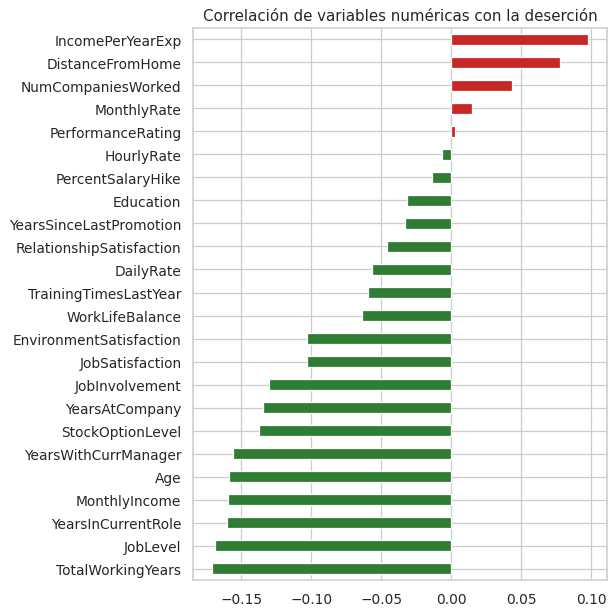

TotalWorkingYears          -0.171
JobLevel                   -0.169
YearsInCurrentRole         -0.161
MonthlyIncome              -0.160
Age                        -0.159
YearsWithCurrManager       -0.156
StockOptionLevel           -0.137
YearsAtCompany             -0.134
JobInvolvement             -0.130
JobSatisfaction            -0.103
EnvironmentSatisfaction    -0.103
WorkLifeBalance            -0.064
TrainingTimesLastYear      -0.059
DailyRate                  -0.057
RelationshipSatisfaction   -0.046
YearsSinceLastPromotion    -0.033
Education                  -0.031
PercentSalaryHike          -0.013
HourlyRate                 -0.007
PerformanceRating           0.003
MonthlyRate                 0.015
NumCompaniesWorked          0.043
DistanceFromHome            0.078
IncomePerYearExp            0.098
Name: Attrition_bin, dtype: float64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [14]:
# Matriz de correlación (variables numéricas) contra el target codificado
df_num = df_clean.copy()
df_num['Attrition_bin'] = (df_num['Attrition']=='Yes').astype(int)
corr = df_num.select_dtypes(include=np.number).corr()['Attrition_bin'].drop('Attrition_bin').sort_values()
fig, ax = plt.subplots(figsize=(7,7))
corr.plot(kind='barh', ax=ax, color=np.where(corr>0,'#c62828','#2e7d32'))
ax.set_title('Correlación de variables numéricas con la deserción')
plt.tight_layout(); plt.show()
print(corr.round(3))

## 5. Modelado — Preparación final (encoding, escalamiento, partición)

Se emplea partición estratificada 70/30 para preservar la proporción de la clase minoritaria (16%). Los modelos supervisados usan `class_weight='balanced'` para compensar el desbalance, priorizando el **Recall** de la clase "Yes": para IBM es más costoso *no detectar* a un empleado que se irá (costo de reemplazo 50-200% del sueldo anual) que intervenir a uno que se quedaría.

In [15]:
# Encoding
X = df_clean.drop(columns=['Attrition','IncomePerYearExp'])
y = (df_clean['Attrition']=='Yes').astype(int)

bin_map = {'OverTime': {'Yes':1,'No':0}, 'Gender': {'Male':1,'Female':0}}
X = X.replace(bin_map)
X = pd.get_dummies(X, columns=['BusinessTravel','Department','EducationField','JobRole','MaritalStatus'], drop_first=True)
print('Matriz final de features:', X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | % Yes en train: {y_train.mean()*100:.1f}%')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Matriz final de features: (1470, 44)
Train: 1029 | Test: 441 | % Yes en train: 16.1%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 6. Aprendizaje Supervisado (3 modelos)

1. **Regresión Logística** — línea base interpretable; los coeficientes indican dirección del riesgo.
2. **Árbol de Decisión** — reglas explícitas comprensibles para RR.HH.
3. **Random Forest** — ensamble robusto, entrega importancia de variables.

In [16]:
modelos = {
    'Regresión Logística': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'Árbol de Decisión':   DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=RANDOM_STATE)
}
resultados = []
probs = {}
for nombre, m in modelos.items():
    Xtr = X_train_s if nombre=='Regresión Logística' else X_train
    Xte = X_test_s  if nombre=='Regresión Logística' else X_test
    m.fit(Xtr, y_train)
    yp = m.predict(Xte)
    ypr = m.predict_proba(Xte)[:,1]
    probs[nombre] = ypr
    resultados.append({'Modelo': nombre,
                       'Accuracy': accuracy_score(y_test, yp),
                       'Precision': precision_score(y_test, yp),
                       'Recall': recall_score(y_test, yp),
                       'F1-Score': f1_score(y_test, yp),
                       'ROC-AUC': roc_auc_score(y_test, ypr)})
tabla = pd.DataFrame(resultados).set_index('Modelo').round(3)
print(tabla)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Modelo                                                             
Regresión Logística     0.757      0.364   0.676     0.473    0.816
Árbol de Decisión       0.732      0.321   0.592     0.416    0.652
Random Forest           0.841      0.529   0.127     0.205    0.762


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

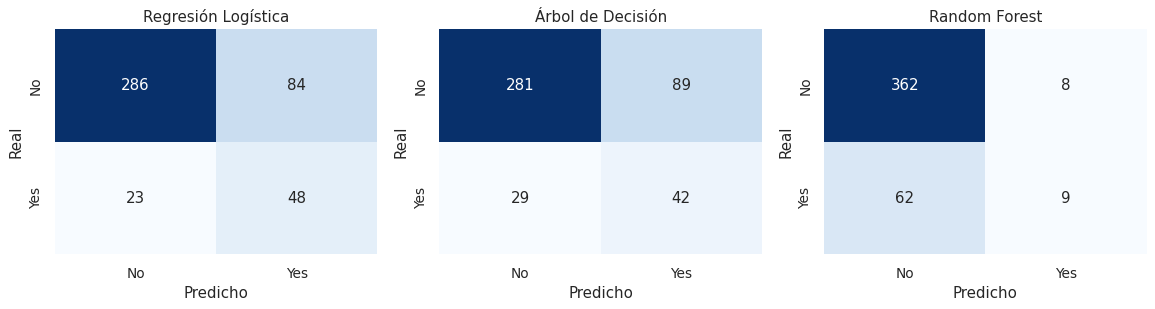

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [17]:
# Matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(13,3.6))
for ax, (nombre, m) in zip(axes, modelos.items()):
    Xte = X_test_s if nombre=='Regresión Logística' else X_test
    cm = confusion_matrix(y_test, m.predict(Xte))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['No','Yes'], yticklabels=['No','Yes'])
    ax.set_title(nombre); ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
plt.tight_layout(); plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

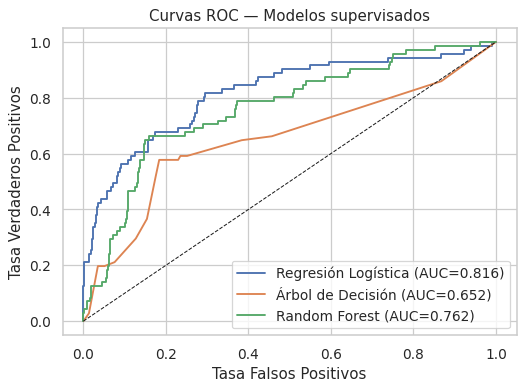

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [18]:
# Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(6,4.5))
for nombre, pr in probs.items():
    fpr, tpr, _ = roc_curve(y_test, pr)
    ax.plot(fpr, tpr, label=f'{nombre} (AUC={roc_auc_score(y_test,pr):.3f})')
ax.plot([0,1],[0,1],'k--', lw=0.8)
ax.set_xlabel('Tasa Falsos Positivos'); ax.set_ylabel('Tasa Verdaderos Positivos')
ax.set_title('Curvas ROC — Modelos supervisados'); ax.legend()
plt.tight_layout(); plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

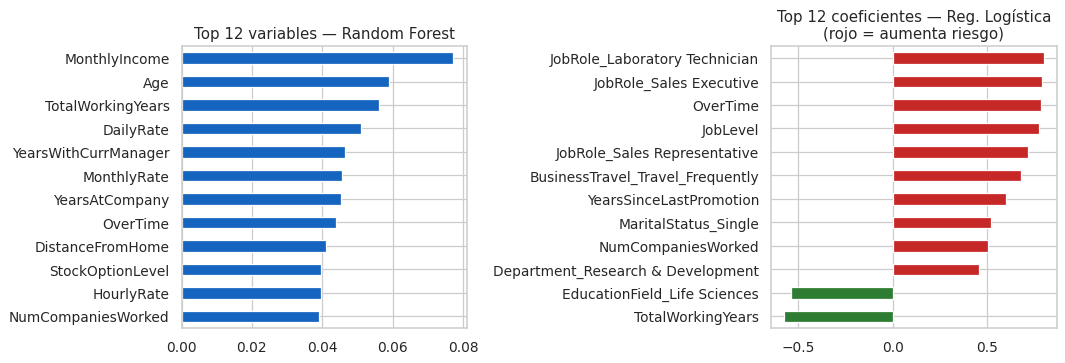

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [19]:
# Importancia de variables (Random Forest) y coeficientes (Reg. Logística)
rf = modelos['Random Forest']
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
lr = modelos['Regresión Logística']
coefs = pd.Series(lr.coef_[0], index=X.columns).sort_values(key=abs, ascending=False).head(12)

fig, ax = plt.subplots(1, 2, figsize=(12,4.2))
imp.sort_values().plot(kind='barh', ax=ax[0], color='#1565c0')
ax[0].set_title('Top 12 variables — Random Forest')
coefs.sort_values().plot(kind='barh', ax=ax[1], color=np.where(coefs.sort_values()>0,'#c62828','#2e7d32'))
ax[1].set_title('Top 12 coeficientes — Reg. Logística\n(rojo = aumenta riesgo)')
plt.tight_layout(); plt.show()

## 7. Aprendizaje No Supervisado (3 técnicas)

1. **K-Means** — segmentación de empleados en grupos de riesgo.
2. **PCA** — reducción de dimensionalidad y visualización de la estructura de los datos.
3. **Apriori (reglas de asociación)** — combinaciones de condiciones asociadas a la deserción.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

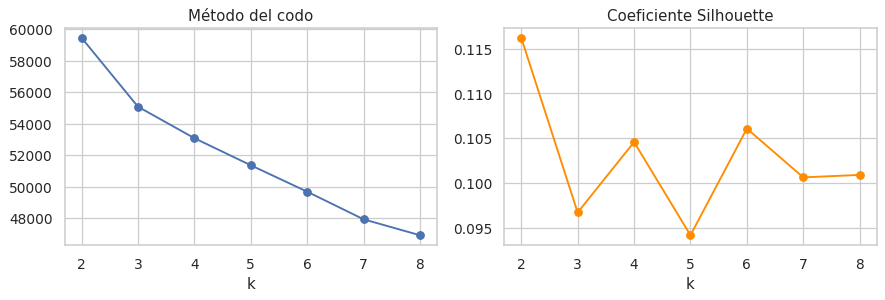

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [20]:
# 7.1 K-Means: método del codo + silhouette
X_scaled_all = StandardScaler().fit_transform(pd.get_dummies(df_clean.drop(columns=['Attrition','IncomePerYearExp']).replace(bin_map),
                    columns=['BusinessTravel','Department','EducationField','JobRole','MaritalStatus'], drop_first=True))
inercias, sils = [], []
K = range(2, 9)
for k in K:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled_all)
    inercias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled_all, km.labels_))
fig, ax = plt.subplots(1,2, figsize=(10,3.5))
ax[0].plot(K, inercias, 'o-'); ax[0].set_title('Método del codo'); ax[0].set_xlabel('k')
ax[1].plot(K, sils, 'o-', color='darkorange'); ax[1].set_title('Coeficiente Silhouette'); ax[1].set_xlabel('k')
plt.tight_layout(); plt.show()

In [21]:
# K-Means con k=3 y perfil de clusters
km = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_scaled_all)
df_clus = df_clean.copy()
df_clus['Cluster'] = km.labels_
perfil = df_clus.groupby('Cluster').agg(
    n=('Age','size'),
    Tasa_Attrition=('Attrition', lambda s: round((s=='Yes').mean()*100,1)),
    Edad_prom=('Age','mean'),
    Sueldo_mediano=('MonthlyIncome','median'),
    Años_empresa=('YearsAtCompany','median'),
    Pct_OverTime=('OverTime', lambda s: round((s=='Yes').mean()*100,1)),
    JobSat_prom=('JobSatisfaction','mean')
).round(1)
print(perfil)
print('\nInterpretación: el cluster con mayor Tasa_Attrition define el "grupo de riesgo" para RR.HH.')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

           n  Tasa_Attrition  Edad_prom  Sueldo_mediano  Años_empresa  \
Cluster                                                                 
0        820            16.5       35.0          3608.5           5.0   
1        399            22.1       35.2          5460.0           5.0   
2        251             5.6       46.0         16015.0          13.0   

         Pct_OverTime  JobSat_prom  
Cluster                             
0                27.6          2.7  
1                29.1          2.8  
2                29.5          2.7  

Interpretación: el cluster con mayor Tasa_Attrition define el "grupo de riesgo" para RR.HH.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Varianza explicada acumulada (10 comp.): [0.121 0.2   0.247 0.292 0.333 0.372 0.408 0.439 0.468 0.497]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

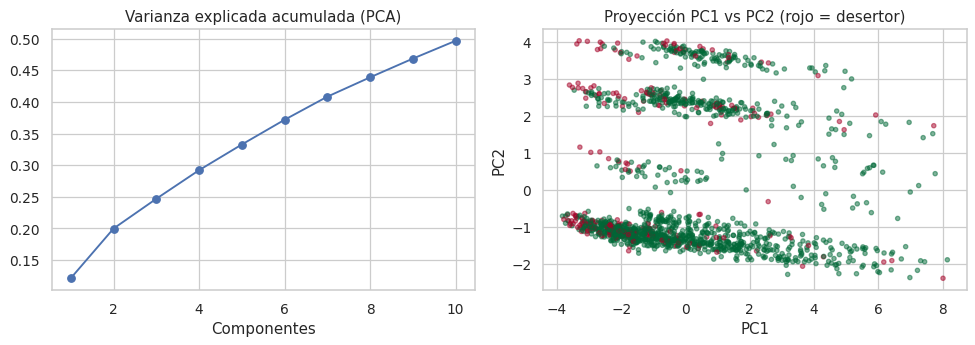

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [22]:
# 7.2 PCA
pca = PCA(n_components=10, random_state=RANDOM_STATE).fit(X_scaled_all)
print('Varianza explicada acumulada (10 comp.):', pca.explained_variance_ratio_.cumsum().round(3))
X_pca = pca.transform(X_scaled_all)
fig, ax = plt.subplots(1,2, figsize=(11,4))
ax[0].plot(range(1,11), pca.explained_variance_ratio_.cumsum(), 'o-')
ax[0].set_title('Varianza explicada acumulada (PCA)'); ax[0].set_xlabel('Componentes')
sc = ax[1].scatter(X_pca[:,0], X_pca[:,1], c=(df_clean['Attrition']=='Yes'), cmap='RdYlGn_r', alpha=0.5, s=12)
ax[1].set_title('Proyección PC1 vs PC2 (rojo = desertor)')
ax[1].set_xlabel('PC1'); ax[1].set_ylabel('PC2')
plt.tight_layout(); plt.show()

In [23]:
# 7.3 Apriori — reglas de asociación hacia Attrition=Yes
bask = pd.DataFrame({
    'OverTime_Si': df_clean['OverTime']=='Yes',
    'Soltero': df_clean['MaritalStatus']=='Single',
    'SueldoBajo': df_clean['MonthlyIncome'] < df_clean['MonthlyIncome'].quantile(0.25),
    'ViajaFrecuente': df_clean['BusinessTravel']=='Travel_Frequently',
    'SatisfBaja': df_clean['JobSatisfaction']<=2,
    'Joven_<30': df_clean['Age']<30,
    'NivelInicial': df_clean['JobLevel']==1,
    'PocaCapacitacion': df_clean['TrainingTimesLastYear']<=1,
    'Attrition_Yes': df_clean['Attrition']=='Yes'
})
freq = apriori(bask, min_support=0.02, use_colnames=True)
reglas = association_rules(freq, metric='confidence', min_threshold=0.3)
reglas_attr = reglas[reglas['consequents'].apply(lambda s: 'Attrition_Yes' in s)]
cols = ['antecedents','support','confidence','lift']
top = reglas_attr.sort_values('lift', ascending=False).head(10)[cols]
top['antecedents'] = top['antecedents'].apply(lambda s: ', '.join(sorted(s)))
print(top.round(3).to_string(index=False))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

                          antecedents  support  confidence  lift
   Joven_<30, OverTime_Si, SueldoBajo    0.024       0.720 7.401
 Joven_<30, NivelInicial, OverTime_Si    0.024       0.537 7.313
              OverTime_Si, SueldoBajo    0.024       0.340 6.320
              OverTime_Si, SueldoBajo    0.042       0.585 6.013
NivelInicial, OverTime_Si, SueldoBajo    0.024       0.353 5.701
              OverTime_Si, SueldoBajo    0.024       0.340 5.486
            NivelInicial, OverTime_Si    0.042       0.397 5.410
               Joven_<30, OverTime_Si    0.024       0.383 5.261
       Joven_<30, Soltero, SueldoBajo    0.024       0.507 5.214
               Joven_<30, OverTime_Si    0.024       0.383 5.213


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 8. Despliegue — Sistema de alerta temprana (propuesta de automatización)

Se utiliza el modelo Random Forest para asignar una **probabilidad de renuncia** a cada empleado. Cuando ésta supera el **70%**, se genera una alerta al gerente de área, priorizando empleados con buen desempeño (PerformanceRating alto).

In [24]:
# Scoring de todos los empleados con el modelo final
prob_all = rf.predict_proba(X)[:,1]
alertas = df_clean.copy()
alertas['Prob_Renuncia'] = (prob_all*100).round(1)
riesgo = alertas[alertas['Prob_Renuncia'] > 70].sort_values('Prob_Renuncia', ascending=False)
print(f'Empleados con probabilidad de renuncia > 70%: {len(riesgo)}')
print(riesgo[['Age','JobRole','JobLevel','MonthlyIncome','OverTime','JobSatisfaction',
              'PerformanceRating','Prob_Renuncia']].head(12).to_string())
print('\nPropuesta de automatización: pipeline mensual (extracción desde el HRIS -> scoring -> ')
print('correo/dashboard Power BI al gerente con la lista priorizada de retención).')

Empleados con probabilidad de renuncia > 70%: 96
      Age                JobRole  JobLevel  MonthlyIncome OverTime  JobSatisfaction  PerformanceRating  Prob_Renuncia
127    19   Sales Representative         1           1675      Yes                3                  3           94.4
463    26  Laboratory Technician         1           2340      Yes                4                  3           92.7
1153   18   Sales Representative         1           1569      Yes                4                  3           90.5
683    25   Sales Representative         1           2413      Yes                2                  3           89.8
1332   29     Research Scientist         1           2439      Yes                4                  4           89.1
296    18  Laboratory Technician         1           1420       No                3                  3           88.8
457    18   Sales Representative         1           1878      Yes                2                  3           88.8
1012   

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 9. Conclusiones

- **H1 confirmada:** las horas extra son el principal factor operativo de riesgo (la tasa de deserción de quienes hacen OverTime triplica aproximadamente la de quienes no).
- **H2 confirmada:** los desertores presentan sueldos significativamente menores, especialmente en relación con sus años de experiencia.
- **H3 confirmada:** viajar frecuentemente y vivir más lejos se asocian a mayor deserción.
- El **perfil del desertor** es un empleado joven (~33 años), soltero, de nivel inicial (JobLevel 1, típicamente Laboratory Technician / Sales Representative), con sobrecarga laboral y baja satisfacción.
- **Variables protectoras no financieras:** mayor capacitación (TrainingTimesLastYear), buena RelationshipSatisfaction y WorkLifeBalance ≥ 3 reducen la tasa de fuga.
- El mejor equilibrio entre Recall y F1 lo entrega la **Regresión Logística balanceada** (mayor Recall) y el **Random Forest** (mayor AUC): se recomienda RF para el scoring y RL para explicar los factores.
- **Recomendaciones:** limitar horas extra estructurales, revisar bandas salariales de niveles iniciales, plan de capacitación mínima anual, trabajo flexible/remoto para quienes viven lejos, y el sistema de alerta >70% integrado al HRIS.
